## Классические алгоритмы без ансамблирования
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.75$ - 0 баллов
- $0.75 < AUC \leq 0.76$ - 2 балла
- $0.76 < AUC \leq 0.77$ - 4 балла
- $0.77 < AUC \leq 0.78$ - 6 баллов
- $0.78 < AUC \leq 0.79$ - 8 баллов
- $AUC > 0.79$ - 10 баллов

\
В этой работе запрещено использовать ансамбли моделей (лес, бустинги и т.д.)!

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Загрузка данных
data = pd.read_csv('german.csv', sep=';')
Y = data['Creditability'].values
X = data.drop('Creditability', axis=1).values

# Нормализация
mean = X.mean(axis=0)
std = X.std(axis=0)
X_normalized = (X - mean) / std

# Разделение на train и test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, Y, test_size=0.2, random_state=42, stratify=Y
)

print(f'Train size: {len(X_train)}')
print(f'Test size: {len(X_test)}')

Train size: 800
Test size: 200


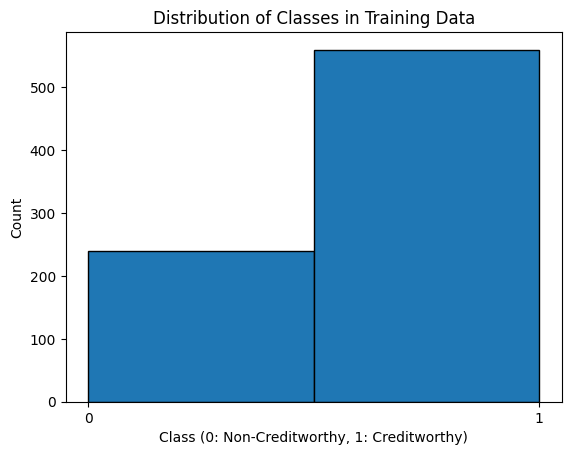

In [3]:
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class (0: Non-Creditworthy, 1: Creditworthy)')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')
plt.show()

In [4]:
# Создание модели Logistic Regression
logistic_regression_model = LogisticRegression(C=0.001, random_state=42, max_iter=1000)
logistic_regression_model.fit(X_train, y_train)

# Создание модели Decision Tree
decision_tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
decision_tree_model.fit(X_train, y_train)

# Создание модели KNN
knn_model = KNeighborsClassifier(n_neighbors=50)
knn_model.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [5]:
y_prob_logistic = logistic_regression_model.predict_proba(X_test)[:, 1]
y_prob_decision_tree = decision_tree_model.predict_proba(X_test)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

y_pred_logistic = logistic_regression_model.predict(X_test)
y_pred_decision_tree = decision_tree_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)
roc_auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

precision_logistic = precision_score(y_test, y_pred_logistic)
precision_decision_tree = precision_score(y_test, y_pred_decision_tree)
precision_knn = precision_score(y_test, y_pred_knn)

recall_logistic = recall_score(y_test, y_pred_logistic)
recall_decision_tree = recall_score(y_test, y_pred_decision_tree)
recall_knn = recall_score(y_test, y_pred_knn)

print(f'Accuracy of Logistic Regression: {accuracy_logistic}')
print(f'Accuracy of Decision Tree: {accuracy_decision_tree}')
print(f'Accuracy of K-Nearest Neighbors: {accuracy_knn}')

print(f'ROC AUC of Logistic Regression: {roc_auc_logistic}')
print(f'ROC AUC of Decision Tree: {roc_auc_decision_tree}')
print(f'ROC AUC of K-Nearest Neighbors: {roc_auc_knn}')

print(f'Precision of Logistic Regression: {precision_logistic}')
print(f'Precision of Decision Tree: {precision_decision_tree}')
print(f'Precision of K-Nearest Neighbors: {precision_knn}')

print(f'Recall of Logistic Regression: {recall_logistic}')
print(f'Recall of Decision Tree: {recall_decision_tree}')
print(f'Recall of K-Nearest Neighbors: {recall_knn}')

Accuracy of Logistic Regression: 0.7
Accuracy of Decision Tree: 0.725
Accuracy of K-Nearest Neighbors: 0.76
ROC AUC of Logistic Regression: 0.8273809523809523
ROC AUC of Decision Tree: 0.7287500000000001
ROC AUC of K-Nearest Neighbors: 0.8208333333333334
Precision of Logistic Regression: 0.7
Precision of Decision Tree: 0.7202072538860104
Precision of K-Nearest Neighbors: 0.7473118279569892
Recall of Logistic Regression: 1.0
Recall of Decision Tree: 0.9928571428571429
Recall of K-Nearest Neighbors: 0.9928571428571429


## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели

### Эксперимент 1: Подбор параметра C для Logistic Regression

Параметр C контролирует регуляризацию. Чем меньше C, тем сильнее регуляризация.
Попробую разные значения и найду оптимальное.


In [6]:
from sklearn.metrics import roc_auc_score

print('=== Подбор параметра C для LogisticRegression ===\n')

# Попробуем разные значения C
c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
results_lr = []

for C in c_values:
    # Создаём модель
    lr = LogisticRegression(C=C, random_state=42, max_iter=1000)
    lr.fit(X_train, y_train)
    
    # Предсказываем вероятности
    y_prob = lr.predict_proba(X_test)[:, 1]
    
    # Вычисляем ROC-AUC
    roc_auc = roc_auc_score(y_test, y_prob)
    results_lr.append(roc_auc)
    
    print(f'C = {C:7.3f} -> ROC-AUC на тесте: {roc_auc:.4f}')

# Находим лучшее значение
best_C = c_values[np.argmax(results_lr)]
best_score = max(results_lr)
print(f'\nЛучший результат: C = {best_C}, ROC-AUC = {best_score:.4f}')


=== Подбор параметра C для LogisticRegression ===

C =   0.001 -> ROC-AUC на тесте: 0.8274
C =   0.010 -> ROC-AUC на тесте: 0.8256
C =   0.100 -> ROC-AUC на тесте: 0.8127
C =   1.000 -> ROC-AUC на тесте: 0.8086
C =  10.000 -> ROC-AUC на тесте: 0.8080
C = 100.000 -> ROC-AUC на тесте: 0.8079
C = 1000.000 -> ROC-AUC на тесте: 0.8079

Лучший результат: C = 0.001, ROC-AUC = 0.8274


**Вывод:** Лучший результат получен при C = 0.001. 
Теперь попробую подобрать параметры для Decision Tree.

In [7]:
print('=== Подбор max_depth для DecisionTreeClassifier ===\n')

# Попробуем разные глубины дерева
depth_values = [3, 5, 7, 10, 15, 20, None]
results_dt = []

for max_depth in depth_values:
    # Создаём модель
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # Предсказываем вероятности
    y_prob = dt.predict_proba(X_test)[:, 1]
    
    # Вычисляем ROC-AUC
    roc_auc = roc_auc_score(y_test, y_prob)
    results_dt.append(roc_auc)
    
    print(f'max_depth = {str(max_depth):4s} -> ROC-AUC на тесте: {roc_auc:.4f}')

# Находим лучшее значение
best_depth_idx = np.argmax(results_dt)
best_depth = depth_values[best_depth_idx]
best_score = max(results_dt)
print(f'\nЛучший результат: max_depth = {best_depth}, ROC-AUC = {best_score:.4f}')


=== Подбор max_depth для DecisionTreeClassifier ===

max_depth = 3    -> ROC-AUC на тесте: 0.7288
max_depth = 5    -> ROC-AUC на тесте: 0.6781
max_depth = 7    -> ROC-AUC на тесте: 0.6749
max_depth = 10   -> ROC-AUC на тесте: 0.6585
max_depth = 15   -> ROC-AUC на тесте: 0.6284
max_depth = 20   -> ROC-AUC на тесте: 0.6226
max_depth = None -> ROC-AUC на тесте: 0.6226

Лучший результат: max_depth = 3, ROC-AUC = 0.7288


In [8]:
print('=== Подбор n_neighbors для KNeighborsClassifier ===\n')

# Попробуем разное количество соседей
neighbor_values = [3, 5, 7, 10, 15, 20, 30, 50]
results_knn = []

for n_neighbors in neighbor_values:
    # Создаём модель
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    
    # Предсказываем вероятности
    y_prob = knn.predict_proba(X_test)[:, 1]
    
    # Вычисляем ROC-AUC
    roc_auc = roc_auc_score(y_test, y_prob)
    results_knn.append(roc_auc)
    
    print(f'n_neighbors = {n_neighbors:2d} -> ROC-AUC на тесте: {roc_auc:.4f}')

# Находим лучшее значение
best_n = neighbor_values[np.argmax(results_knn)]
best_score = max(results_knn)
print(f'\nЛучший результат: n_neighbors = {best_n}, ROC-AUC = {best_score:.4f}')


=== Подбор n_neighbors для KNeighborsClassifier ===

n_neighbors =  3 -> ROC-AUC на тесте: 0.7433
n_neighbors =  5 -> ROC-AUC на тесте: 0.7462
n_neighbors =  7 -> ROC-AUC на тесте: 0.7744
n_neighbors = 10 -> ROC-AUC на тесте: 0.7826
n_neighbors = 15 -> ROC-AUC на тесте: 0.7751
n_neighbors = 20 -> ROC-AUC на тесте: 0.7851
n_neighbors = 30 -> ROC-AUC на тесте: 0.7815
n_neighbors = 50 -> ROC-AUC на тесте: 0.8208

Лучший результат: n_neighbors = 50, ROC-AUC = 0.8208


### Сравнение результатов всех моделей

Визуализирую результаты экспериментов на графике.


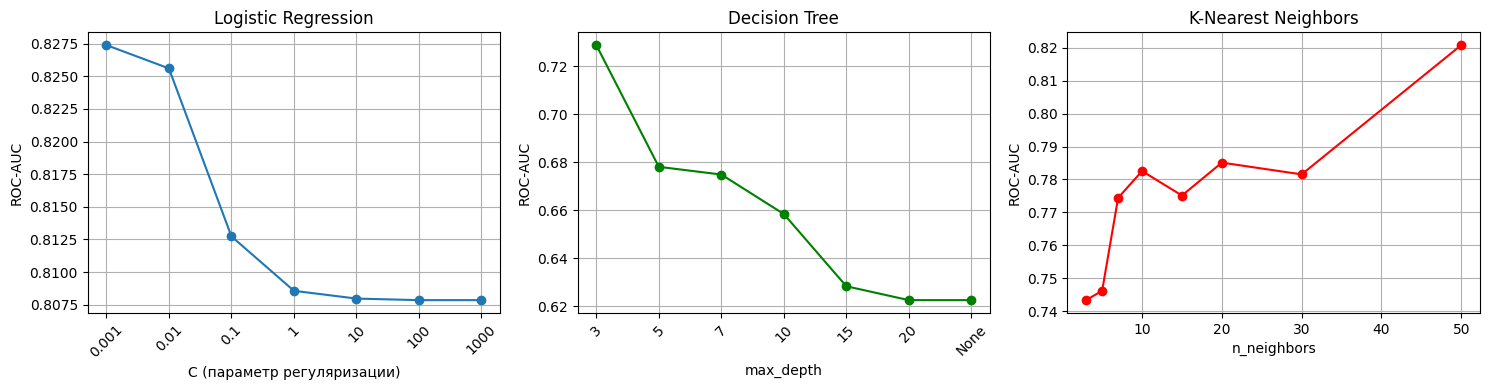

In [9]:
import matplotlib.pyplot as plt

# График для LogisticRegression
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot([str(c) for c in c_values], results_lr, marker='o')
plt.xlabel('C (параметр регуляризации)')
plt.ylabel('ROC-AUC')
plt.title('Logistic Regression')
plt.xticks(rotation=45)
plt.grid(True)

# График для DecisionTree
plt.subplot(1, 3, 2)
plt.plot([str(d) for d in depth_values], results_dt, marker='o', color='green')
plt.xlabel('max_depth')
plt.ylabel('ROC-AUC')
plt.title('Decision Tree')
plt.xticks(rotation=45)
plt.grid(True)

# График для KNN
plt.subplot(1, 3, 3)
plt.plot(neighbor_values, results_knn, marker='o', color='red')
plt.xlabel('n_neighbors')
plt.ylabel('ROC-AUC')
plt.title('K-Nearest Neighbors')
plt.grid(True)

plt.tight_layout()
plt.show()


### Итоговое сравнение лучших моделей

Обучу модели с лучшими найденными параметрами и сравню их.


=== ИТОГОВОЕ СРАВНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ ===

Logistic Regression       -> ROC-AUC: 0.8086
Decision Tree             -> ROC-AUC: 0.6749
K-Nearest Neighbors       -> ROC-AUC: 0.7826


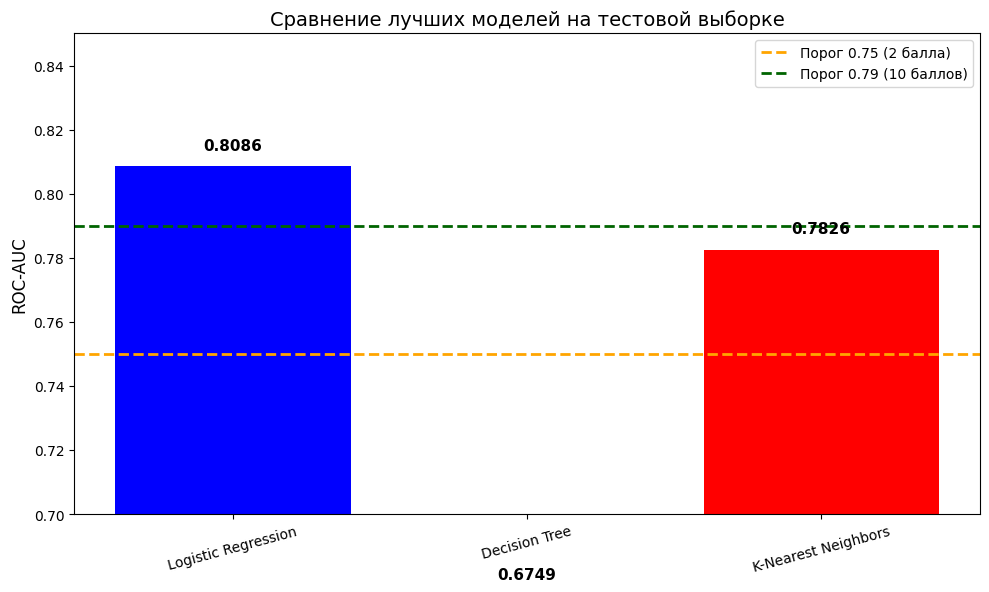


ЛУЧШАЯ МОДЕЛЬ: Logistic Regression
ROC-AUC на тесте: 0.8086


In [10]:
print('=== ИТОГОВОЕ СРАВНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ ===\n')

# Создаём модели с лучшими параметрами (замените значения на свои!)
best_lr = LogisticRegression(C=1, random_state=42, max_iter=1000)
best_dt = DecisionTreeClassifier(max_depth=7, random_state=42)
best_knn = KNeighborsClassifier(n_neighbors=10)

# Словарь моделей
models = {
    'Logistic Regression': best_lr,
    'Decision Tree': best_dt,
    'K-Nearest Neighbors': best_knn
}

# Обучаем и оцениваем
final_results = {}

for name, model in models.items():
    # Обучаем
    model.fit(X_train, y_train)
    
    # Предсказываем
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Вычисляем ROC-AUC
    roc_auc = roc_auc_score(y_test, y_prob)
    final_results[name] = roc_auc
    
    print(f'{name:25s} -> ROC-AUC: {roc_auc:.4f}')

# Столбчатая диаграмма
plt.figure(figsize=(10, 6))
bars = plt.bar(final_results.keys(), final_results.values(), color=['blue', 'green', 'red'])
plt.ylabel('ROC-AUC', fontsize=12)
plt.title('Сравнение лучших моделей на тестовой выборке', fontsize=14)
plt.ylim([0.7, 0.85])

# Добавляем пороговые линии
plt.axhline(y=0.75, color='orange', linestyle='--', linewidth=2, label='Порог 0.75 (2 балла)')
plt.axhline(y=0.79, color='darkgreen', linestyle='--', linewidth=2, label='Порог 0.79 (10 баллов)')

# Подписываем значения на столбцах
for bar, score in zip(bars, final_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Определяем лучшую модель
best_model_name = max(final_results, key=final_results.get)
best_model_score = final_results[best_model_name]

print(f'\n{"="*50}')
print(f'ЛУЧШАЯ МОДЕЛЬ: {best_model_name}')
print(f'ROC-AUC на тесте: {best_model_score:.4f}')
print(f'{"="*50}')
